# Сахарный диабет
У нас имеется выборка с пациентами и их данными: общей информацией, анализами, наличием болезней. 


**Цель:** обучить модель машинного обучения для прогнозирования сахарного диабета.

In [1]:
!pip install phik -q

In [2]:
# необходимые импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math
import phik

from sklearn.model_selection import (train_test_split, 
                                     GridSearchCV)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (make_scorer, f1_score, accuracy_score, confusion_matrix, precision_score, recall_score)

from tqdm.notebook import tqdm
tqdm.pandas()

In [3]:
# константы
RANDOM_STATE = 654321
TEST_SIZE = 0.3

# Загрузка данных

In [4]:
def set_pandas_options():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_colwidth', 50)
    pd.set_option('display.float_format', '{:.2f}'.format)

set_pandas_options()

In [5]:
data = pd.read_excel('diabetes_ds.xlsx')
data = data.copy()

data.head()

,Номер,Перенес/ не перенес КВИ,Возраст,Пол,"Рост, см","Вес, кг",ИМТ 2 (ФОРМУЛА EXCEL),Эритроциты,Гемоглобин,Цветовой показатель,Лейкоциты,Лимфоциты%,"ЛИМФОЦИТЫ, АБС (РАСЧЕТ ПО ФОРМУЛЕ)",Тромбоциты,СОЭ,Холестерин,ЛПНП,ЛПВП,Индекс атерогенности 2 (формула excel),Глюкоза,Гликированный гемоглобин,СРБ,Ферритин,Прокальцитонин,Альбумин,Лактат,ЛДГ,АЛТ,АСТ,Общий билирубин,Натрийуретический пептид,Мочевина,"Креатинин, мкмоль/л",СКФ CKD-EPI (расчет по общей формуле),Натрий,Калий,АЧТВ,МНО,Фибриноген,D-димер,Фавипиравир,Молнупиравир,Гидрохлортиазид,Фуросемид,Торасемид,Спиронолактон,Валсартан,Телмисартан,Лозартан,Кандесартан,Изосорбида динитрат,Периндоприл,Рамиприл,Эналаприл,Лизиноприл,Бисопролол,Карведилол,Атенолол,Верапамил,Дилтиазем,Леркамен,Амлодипин,Дигоксин,Ивабрадин,Гиполипидемические препараты (статины),"Антикоагулянты, препарат","Антикоагулянты, препарат 2","Антиагреганты, препарат 1","Антиагреганты, препарат 2",Триметазидин,Метформин,Дапаглифлозин,СТЕПЕНИ ОЖИРЕНИЯ ПО ИМТ,ОЖИРЕНИЕ (ЕСТЬ\НЕТ),BPB голеней,BPB голеней (ЕСТЬ/НЕТ),Тромбоэмболический синдром,ВПС,НЕАЖБП,Гипертрофия миокарда левого желудочка по ЭКГ или ЭХО-КГ,Гипертрофия миокарда левого желудочка по ЭКГ или ЭХО-КГ (комментарий),Блокада НП Гисса,Блокада НП Гисса (комментарий),Удлинение интервала QT,AV- блокада,ХБП (исходн),ХБП (расчет по СКФ),ХБП (ЕСТЬ\НЕТ),Мерцательная аритмия,Мерцательная аритмия (ЕСТЬ\НЕТ),Аблация,АКШ,БА,БА (ЕСТЬ/НЕТ),ХОБЛ,ХОБЛ (ЕСТЬ\НЕТ),ИБС. Стенокардия,ИБС. Стенокардия (ЕСТЬ\НЕТ),ИБС. ПИКС,ИБС. ПИКС (ЕСТЬ\НЕТ),"АГ, стадия",АГ (ЕСТЬ\НЕТ),"АГ, степень","АГ, риск","ХСН, стадии","ХСН, ФК","ХСН по фракции выброса, %",Сахарный диабет (ЕСТЬ\НЕТ)
0,390.00,1.00,68.00,2.00,158.00,86.00,34.45,5.33,163.00,0.00,9.61,31.90,3.07,201.00,8.00,4.14,2.25,0.97,3.27,5.77,6.50,0.19,NaN,NaN,NaN,NaN,NaN,24.00,21.00,NaN,197.70,NaN,79.80,65.46,NaN,5.76,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,NaN,1.00,NaN,0.00,1.00,1.00,1.00,1.00,0,0.00,0.00,0.00,1.00,0.00,NaN,0,NaN,0.00,0,0,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,2.00,0,1.00
1,337.00,1.00,54.00,1.00,180.00,119.00,36.73,5.01,130.00,0.00,10.48,19.00,1.99,288.00,5.00,3.43,1.31,1.19,1.88,5.91,6.10,NaN,NaN,NaN,46.00,NaN,NaN,12.00,14.00,NaN,2358.00,10.10,107.28,67.22,140.40,4.38,38.20,2.34,3.71,NaN,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,NaN,1.00,NaN,0.00,1.00,1.00,2.00,1.00,1,1.00,1.00,0.00,0.00,1.00,умеренная гипертрофия,1,полная блокада,0.00,0,с3б,2.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,3.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,3.00,35,1.00
2,160.00,1.00,68.00,1.00,174.00,110.00,36.33,NaN,161.00,0.00,5.40,25.60,1.38,114.00,10.00,4.23,2.69,0.94,3.50,6.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.50,20.70,18.10,NaN,NaN,106.20,61.68,140.60,4.30,33.70,NaN,NaN,NaN,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,NaN,1.00,NaN,0.00,0.00,0.00,2.00,1.00,1,1.00,0.00,0.00,0.00,1.00,NaN,1-2,NaN,0.00,1,с3,2.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,3.00,3.00,35,1.00
3,166.00,1.00,67.00,1.00,189.00,110.00,30.79,4.47,134.00,0.00,8.50,13.30,1.13,175.00,5.00,NaN,NaN,NaN,NaN,4.98,NaN,20.35,NaN,NaN,43.60,NaN,327.00,17.90,23.80,23.30,454.60,10.78,91.20,74.67,140.60,4.00,26.30,1.09,3.68,NaN,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,NaN,1.00,NaN,0.00,1.00,0.00,1.00,1.00,0,0.00,0.00,0.00,0.00,0.00,NaN,1,NaN,0.00,1,0,2.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,2.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,3.00,3.00,0,1.00
4,439.00,1.00,60.00,1.00,178.00,115.00,36.30,5.44,166.00,0.00,9.06,28.30,2.56,226.00,5.00,3.25,1.45,1.30,1.50,9.48,7.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280.70,3.20,81.70,8

In [6]:
# общая информация
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 108 columns):
 #    Column                                                                 Non-Null Count  Dtype  
---   ------                                                                 --------------  -----  
 0    Номер                                                                  482 non-null    float64
 1    Перенес/ не перенес КВИ                                                482 non-null    float64
 2    Возраст                                                                481 non-null    float64
 3    Пол                                                                    482 non-null    float64
 4    Рост, см                                                               481 non-null    float64
 5    Вес, кг                                                                481 non-null    float64
 6    ИМТ 2 (ФОРМУЛА EXCEL)                                                  482 non-n

У нас 108 признаков на 484 наблюдения. Имеются пропуски, признаки имеют тип данных float и object. Есть подозрение на задваивание признаков.
Названия столбцов не приведены к змеиному регистру.

**Вывод:** выгрузили данные, посмотрели общую информацию о файлах. Не все данные соответствуют описанию.

Названия столбцов не приведены к змеиному регистру, тип данных не соответствует `BPB голеней`, `ХСН по фракции выброса, %`.

# Предобработка данных

Переименуем названия столбцов, обработаем пропуски, поищем дубликаты, приведем тип данных к правильному типу.

In [7]:
data.columns = ['number', 'covid', 'age', 'sex', 'height', 'weight', 'body_mass_index',
               'red_blood_cells', 'hemoglobin', 'color_indicator', 'white_blood_cells',
               'lymphocytes_%', 'lymphocytes_abs', 'thrombocytes', 'soe', 'cholesterol',
               'lpnp', 'lpvp', 'atherogenicity_index', 'glucose', 'glycated_hemoglobin',
               'c_reactive_protein', 'ferritin', 'procalcitonin', 'albumin', 'lactate',
               'ldg', 'alt', 'ast', 'total_bilirubin', 'natriuretic_peptide', 'urea',
               'creatinine_mkmol_l', 'skf_ckd_epi', 'na', 'k', 'actv', 'mno', 'fibrinogen',
               'd_dimer', 'favipiravir', 'molnupiravir', 'hclthiazide', 'furosemide', 
               'torasemide', 'spironolactone', 'valsartan', 'telmisartan', 'losartan',
               'candesartan', 'isosorbide_dinitrate', 'perindopril', 'ramipril', 'enalapril',
                'lisinopril', 'bisoprolol', 'carvedilol', 'atenolol', 'verapamil', 'diltiazem',
                'lercamen', 'amlodipine', 'digoxin', 'ivabradine', 'lipid_lowering_drugs_statins',
                'anticoagulants_drug_1', 'anticoagulants_drug_2', 'antiplatelet_agents_drug_1',
                'antiplatelet_agents_drug_2', 'trimetazidine', 'metformin', 'dapagliflozin',
                'degree_of_obesity_bmi', 'obesity', 'bpb_of_shins', 'bpb_of_lower_shins_yn',
                'thromboembolic_syndrome', 'сongenital_heart_defects', 'non_alcoholic_fatty_liver_disease',
                'left_ventricular_myocardial_hypertrophy', 'left_ventricular_myocardial_hypertrophy_comment',
                'gissa_inventory_item_blockade', 'gissa_inventory_item_blockade_comment',
                'qt_interval_prolongation', 'av_block', 'chronic_kidney_disease_initial',
                'chronic_kidney_disease_skf', 'chronic_kidney_disease_yn', 'atrial_fibrillation',
                'atrial_fibrillation_yn', 'ablation', 'aksh', 'ba', 'ba_yn', 'hobl', 'hobl_yn',
                'ibs_stenocardia', 'ibs_stenocardia_yn', 'ibs_piks', 'ibs_piks_yn', 'ag_stage',
                'ag_yn', 'ag_degree', 'ag_risk', 'hsn_stages',  'hsn_fc', 'hsn_ejection_fraction_%',
                'target']

In [8]:
# посмотрим количество пропусков
data.isna().sum()

number                                               2
covid                                                2
age                                                  3
sex                                                  2
height                                               3
weight                                               3
body_mass_index                                      2
red_blood_cells                                      5
hemoglobin                                           2
color_indicator                                      3
white_blood_cells                                    3
lymphocytes_%                                        3
lymphocytes_abs                                      4
thrombocytes                                         6
soe                                                 48
cholesterol                                         25
lpnp                                                38
lpvp                                                45
atherogeni

Отберем признаки по следующим параметрам:

- Уровень пропусков < 30%;
- Удалим дублирующие признаки;
- Удалим признаки, которые будут создавать утечку таргета;
- Клиническая релевантность для диабета.

In [9]:
# проценты пропусков
missing_percent = (data.isnull().sum() / len(data) * 100).round(2)
missing_df = pd.DataFrame({
    'Признак': missing_percent.index,
    'Пропуски (%)': missing_percent.values,
    'Количество пропусков': data.isnull().sum().values
})

# сортировка по убыванию процента пропусков
missing_df = missing_df.sort_values('Пропуски (%)', ascending=False).reset_index(drop=True).head(20)
missing_df.style.hide(axis='index')
missing_df


,Признак,Пропуски (%),Количество пропусков
0,procalcitonin,99.59,482
1,lactate,97.93,474
2,anticoagulants_drug_2,97.52,472
3,antiplatelet_agents_drug_2,96.49,467
4,left_ventricular_myocardial_hypertrophy_comment,94.63,458
5,ferritin,93.80,454
6,gissa_inventory_item_blockade_comment,91.53,443
7,ldg,91.53,443
8,d_dimer,87.40,423
9,fibrinogen,78.72,381


Удалим первые 19 признаков **по количеству пропусков**

In [10]:
# удаление по пропускам
data = data.drop(columns = missing_df['Признак'][:19].tolist())
data.sample(5)

,number,covid,age,sex,height,weight,body_mass_index,red_blood_cells,hemoglobin,color_indicator,white_blood_cells,lymphocytes_%,lymphocytes_abs,thrombocytes,soe,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,alt,ast,natriuretic_peptide,urea,creatinine_mkmol_l,skf_ckd_epi,favipiravir,molnupiravir,hclthiazide,furosemide,torasemide,spironolactone,valsartan,telmisartan,losartan,candesartan,isosorbide_dinitrate,perindopril,ramipril,enalapril,lisinopril,bisoprolol,carvedilol,atenolol,verapamil,diltiazem,lercamen,amlodipine,digoxin,ivabradine,lipid_lowering_drugs_statins,anticoagulants_drug_1,trimetazidine,metformin,dapagliflozin,degree_of_obesity_bmi,obesity,bpb_of_shins,bpb_of_lower_shins_yn,thromboembolic_syndrome,сongenital_heart_defects,non_alcoholic_fatty_liver_disease,left_ventricular_myocardial_hypertrophy,gissa_inventory_item_blockade,qt_interval_prolongation,av_block,chronic_kidney_disease_initial,chronic_kidney_disease_skf,chronic_kidney_disease_yn,atrial_fibrillation,atrial_fibrillation_yn,ablation,aksh,ba,ba_yn,hobl,hobl_yn,ibs_stenocardia,ibs_stenocardia_yn,ibs_piks,ibs_piks_yn,ag_stage,ag_yn,ag_degree,ag_risk,hsn_stages,hsn_fc,hsn_ejection_fraction_%,target
204,321.00,1.00,68.00,1.00,175.00,110.00,35.92,5.17,159.00,0.00,13.90,19.70,2.74,254.00,9.00,2.88,1.81,0.72,3.00,8.06,16.50,24.30,309.00,8.11,117.00,54.86,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,0.00,0.00,2.00,1.00,0,0.00,0.00,0.00,0.00,1.00,0,0.00,0,0,3.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,1.00,3.00,4.00,2.00,2.00,20,1.00
80,245.00,1.00,65.00,1.00,185.00,122.00,35.65,4.90,166.00,0.00,9.00,26.20,2.36,177.00,6.00,4.68,2.23,1.82,1.57,9.60,27.40,35.30,727.00,5.01,97.00,70.28,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,2.00,1.00,0,0.00,0.00,0.00,0.00,0.00,1,0.00,0,0,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,2.00,40,1.00
444,453.00,2.00,48.00,1.00,190.00,103.00,28.53,5.12,156.00,0.00,7.02,24.01,1.69,314.80,NaN,3.44,NaN,NaN,NaN,12.95,10.90,19.00,3150.00,4.40,107.00,70.34,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,0,0.00,0.00,0.00,0.00,1.00,0,0.00,0,0,2.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,1.00,3.00,4.00,2.00,2.00,21,1.00
400,361.00,2.00,67.00,1.00,187.00,85.00,24.31,5.13,180.00,0.00,6.35,31.30,1.99,188.00,6.00,6.48,4.31,1.30,3.98,4.66,20.00,22.00,275.00,5.00,93.60,72.36,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,NaN,0.00,0.00,0.00,0.00,0.00,0,0.00,1.00,0.00,0.00,0.00,0,0.00,0,0,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,3.00,1.00,0.00,4.00,2.00,2.00,40,0.00
106,237.00,1.00,53.00,1.00,170.00,83.00,28.72,4.90,149.00,0.00,12.00,34.00,4.08,362.00,15.00,3.59,2.04,1.10,2.26,3.59,18.17,NaN,129.15,4.90,98.10,75.43,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,4.00,0.00,0,0.00,0.00,0.00,0.00,1.00,0,0.00,0,0,2.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,2.00,48,1.00


Посмотрим на **дублирующие признаки**

`degree_of_obesity_bmi` и `obesity`;

`chronic_kidney_disease_initial`, `chronic_kidney_disease_skf`, `chronic_kidney_disease_yn`;

`atrial_fibrillation` и `atrial_fibrillation_yn`;

`ba`и `ba_yn` - удалим оба, тк нерелевантны для диабета;

`hobl` и `hobl_yn`- удалим оба, тк нерелевантны;

`ibs_stenocardia` и `ibs_stenocardia_yn`;

`ibs_piks` и `ibs_piks_yn`;

`ag_stage`, `ag_yn`, `ag_degree`, `ag_risk`;

`hsn_stages`, `hsn_fc`, `hsn_ejection_fraction_%`.

In [11]:
# визуализация степени ожирения и наличия ожирения
data[['body_mass_index','degree_of_obesity_bmi', 'obesity', 
      'chronic_kidney_disease_initial', 'chronic_kidney_disease_skf', 'chronic_kidney_disease_yn',
      'atrial_fibrillation', 'atrial_fibrillation_yn', 
      'ibs_stenocardia', 'ibs_stenocardia_yn',
      'ibs_piks', 'ibs_piks_yn',
      'ag_stage', 'ag_yn', 'ag_degree', 'ag_risk',
      'hsn_stages', 'hsn_fc', 'hsn_ejection_fraction_%']].sample(10)

,body_mass_index,degree_of_obesity_bmi,obesity,chronic_kidney_disease_initial,chronic_kidney_disease_skf,chronic_kidney_disease_yn,atrial_fibrillation,atrial_fibrillation_yn,ibs_stenocardia,ibs_stenocardia_yn,ibs_piks,ibs_piks_yn,ag_stage,ag_yn,ag_degree,ag_risk,hsn_stages,hsn_fc,hsn_ejection_fraction_%
325,29.05,4.00,0.00,0,2.00,1.00,0.00,0.00,2.00,1.00,0.00,0.00,3.00,1.00,3.00,4.00,3.00,2.00,46-48
352,30.04,1.00,1.00,с2,NaN,NaN,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,1.00,4.00,2.00,3.00,20
37,21.30,0.00,0.00,0,2.00,1.00,0.00,0.00,3.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,2.00,42
302,37.32,2.00,1.00,с3а,2.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,2.00,38
398,21.63,0.00,0.00,0,2.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,3.00,4.00,3.00,4.00,31
342,29.32,4.00,0.00,0,3.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,1.00,1.00,4.00,2.00,0.00,0
199,35.55,2.00,1.00,0,3.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,1.00,0.00,4.00,3.00,3.00,50
258,31.74,1.00,1.00,0,2.00,1.00,0.00,0.00,2.00,1.00,1.00,1.00,3.00,1.00,3.00,4.00,2.00,0.00,27
370,30.80,1.00,1.00,с1,3.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,3.00,1.00,3.00,4.00,3.00,3.00,22
85,32.37,1.00,1.00,с3,3.00,1.00,2.00,1.00,0.00,0.00,1.00,1.00,3.00,1.00,0.00,4.00,2.00,2.00,27


Видим, что столбец `degree_of_obesity_bmi` не информативен - при отсутствии ожирения, ИМТ<30, иногда встречается 4 степень, например, индекс 105, 170, 365.

Удалим `chronic_kidney_disease_initial` и `chronic_kidney_disease_skf`, оставим `chronic_kidney_disease_yn`, тк бинарный признак понятнее.

Наличие мерцательной аритмии показательнее, чем стадии.

Удалим `ibs_stenocardia`, оставив `ibs_stenocardia_yn`.

Удалим `ibs_piks`.

Оставим `ag_yn` - есть/нет гипертонии как наиболее информативный и простой.

Оставим `hsn_ejection_fraction_%`, тк числовой, более информативный.

`skf_ckd_epi` рассчитан из `creatinine_mkmol_l`, `age`, `sex`. Удалим `creatinine_mkmol_l`

Рост и вес уже учтены в ИМТ, их тоже удалим.

In [12]:
# дублирующие признаки на удаление
list_delete = ['height', 'weight', 'degree_of_obesity_bmi','chronic_kidney_disease_initial', 'chronic_kidney_disease_skf',
               'atrial_fibrillation', 'ba', 'ba_yn', 'hobl', 'hobl_yn', 'ibs_stenocardia', 'ibs_piks',
               'ag_stage',	'ag_degree', 'ag_risk', 'hsn_stages', 'hsn_fc', 'creatinine_mkmol_l']

data = data.drop(columns = list_delete)

data.sample(5)

,number,covid,age,sex,body_mass_index,red_blood_cells,hemoglobin,color_indicator,white_blood_cells,lymphocytes_%,lymphocytes_abs,thrombocytes,soe,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,alt,ast,natriuretic_peptide,urea,skf_ckd_epi,favipiravir,molnupiravir,hclthiazide,furosemide,torasemide,spironolactone,valsartan,telmisartan,losartan,candesartan,isosorbide_dinitrate,perindopril,ramipril,enalapril,lisinopril,bisoprolol,carvedilol,atenolol,verapamil,diltiazem,lercamen,amlodipine,digoxin,ivabradine,lipid_lowering_drugs_statins,anticoagulants_drug_1,trimetazidine,metformin,dapagliflozin,obesity,bpb_of_shins,bpb_of_lower_shins_yn,thromboembolic_syndrome,сongenital_heart_defects,non_alcoholic_fatty_liver_disease,left_ventricular_myocardial_hypertrophy,gissa_inventory_item_blockade,qt_interval_prolongation,av_block,chronic_kidney_disease_yn,atrial_fibrillation_yn,ablation,aksh,ibs_stenocardia_yn,ibs_piks_yn,ag_yn,hsn_ejection_fraction_%,target
375,392.00,2.00,60.00,2.00,33.80,4.70,158.00,0.00,5.30,2.30,0.12,278.00,4.00,3.22,1.58,1.18,1.73,5.08,NaN,NaN,1229.63,NaN,47.39,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,1.00,0,0.00,0.00,0.00,0.00,0.00,1,0.00,0,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0,0.00
383,438.00,2.00,62.00,1.00,30.45,5.10,159.00,0.00,6.20,24.00,1.49,242.00,6.00,5.40,2.97,NaN,NaN,5.40,30.00,41.00,NaN,NaN,64.85,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,1.00,1.00,0,0.00,0.00,0.00,0.00,1.00,1,0.00,0,1.00,0.00,0.00,0.00,0.00,1.00,1.00,38,0.00
296,238.00,2.00,60.00,1.00,37.87,5.40,172.00,0.00,12.60,12.00,1.51,284.00,NaN,NaN,NaN,NaN,NaN,10.60,25.00,19.00,4671.00,16.80,30.35,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,2.00,0.00,0.00,1.00,1.00,0,0.00,0.00,0.00,0.00,0.00,1,0.00,0,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0,1.00
168,442.00,1.00,62.00,1.00,24.22,2.74,61.00,0.00,7.90,34.40,2.72,227.00,30.00,3.07,1.23,0.83,2.70,5.58,41.00,63.00,2216.00,8.60,75.92,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,4.00,0.00,0.00,1.00,0.00,0,0.00,0.00,0.00,0.00,1.00,0,0.00,0,1.00,1.00,0.00,0.00,0.00,1.00,1.00,40,0.00
284,172.00,2.00,58.00,1.00,41.47,6.26,160.00,0.00,12.20,25.30,3.09,191.00,3.00,4.03,1.35,1.08,2.73,5.33,36.90,33.10,2090.00,5.31,62.52,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,0.00,0.00,1.00,1.00,1.00,0,0.00,0.00,0.00,1.00,0.00,0,0.00,0,1.00,0.00,0.00,0.00,0.00,1.00,1.00,46,1.00


Удалим признаки `metformin`, `dapagliflozin`, тк их назначают при выявленном сахарном диабете.

In [13]:
# удаление признаков с утечкой
data = data.drop(columns = ['metformin', 'dapagliflozin'])
data.sample()

,number,covid,age,sex,body_mass_index,red_blood_cells,hemoglobin,color_indicator,white_blood_cells,lymphocytes_%,lymphocytes_abs,thrombocytes,soe,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,alt,ast,natriuretic_peptide,urea,skf_ckd_epi,favipiravir,molnupiravir,hclthiazide,furosemide,torasemide,spironolactone,valsartan,telmisartan,losartan,candesartan,isosorbide_dinitrate,perindopril,ramipril,enalapril,lisinopril,bisoprolol,carvedilol,atenolol,verapamil,diltiazem,lercamen,amlodipine,digoxin,ivabradine,lipid_lowering_drugs_statins,anticoagulants_drug_1,trimetazidine,obesity,bpb_of_shins,bpb_of_lower_shins_yn,thromboembolic_syndrome,сongenital_heart_defects,non_alcoholic_fatty_liver_disease,left_ventricular_myocardial_hypertrophy,gissa_inventory_item_blockade,qt_interval_prolongation,av_block,chronic_kidney_disease_yn,atrial_fibrillation_yn,ablation,aksh,ibs_stenocardia_yn,ibs_piks_yn,ag_yn,hsn_ejection_fraction_%,target
301,50.00,2.00,53.00,1.00,30.67,4.83,157.00,0.00,11.68,22.60,2.64,200.00,22.00,6.42,3.95,1.31,3.90,5.06,14.00,23.00,2989.00,7.12,70.78,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,4.00,0.00,1.00,0,0.00,0.00,0.00,0.00,1.00,1,0.00,0,1.00,0.00,0.00,0.00,0.00,1.00,1.00,32,1.00


**Клиническая релевантность** для диабета:

`age`, `sex`, `body_mass_index`, `hemoglobin`, `cholesterol`, `lpnp`, `lpvp`, `atherogenicity_index`, `glucose`, `urea`, `skf_ckd_epi`, `obesity`, `non_alcoholic_fatty_liver_disease`, `chronic_kidney_disease_yn`, `ag_yn`, `hsn_ejection_fraction_%`, `target`. 

Нерелеванты оставшиеся, включая лекарственные препараты, тк прием препаратов — это уже следствие медицинского наблюдения и подозрения на метаболические проблемы. Модель, увидев связь "прием статина -> высокий риск диабета", научится не предсказывать диабет, а выявлять пациентов, которые уже находятся под наблюдением врача.


In [14]:
# релевантные признаки для СД
data = data[['number', 'age', 'sex',  'body_mass_index', 'hemoglobin', 'cholesterol', 'lpnp', 'lpvp',
    'atherogenicity_index', 'glucose', 'urea', 'skf_ckd_epi', 'obesity', 'non_alcoholic_fatty_liver_disease',
    'chronic_kidney_disease_yn', 'ag_yn', 'hsn_ejection_fraction_%', 'target']]

print('Количество признаков =', len(data.columns))

Количество признаков = 18


In [15]:
# уникальные значения в столбцах
for i in data.columns:
    print('\033[1m', i, '\033[0m')
    try:
        display(data[i].sort_values().unique())
    except:
        display(data[i].unique())
    print()

 number 


array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 15


 age 


array([35., 41., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54.,
       55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67.,
       68., 69., 70., 71., 83., nan])


 sex 


...

array([  0.,   1., 445.,  nan])


 hsn_ejection_fraction_% 


array([0, 35, 40, 42, 34, 31, 33, 23, 29, 41, 38, '24-25', 30, 27, 32, 36,
       50, 45, 37, '25.9', 28, 39, 58, 26, 51, '22-25', 59, 46, 25,
       '40-45', 48, '32-36', 43, 49, 20, '20-25', '39-40', '15-20', 18,
       24, '34-35', '30-31', '28-30', 47, 54, 22, 61, 21, 66, '42-43',
       '36-38', '30-32', 'с2', '28.9', '43.4', '32-33', '30-35', 44,
       '34-36', '40-41', 17, '33-48', '33-35', '46-48', '38-40', '35-37',
       '21-25', '24-26', '33-52', '37-47', '23-25', '55-56', '20-32',
       '18-20', 57, nan], dtype=object)


 target 


array([ 0.,  1., nan])

По первому столбцу с номером наблюдения не хватает 483 и 484 номеров. Посмотрим, что там записано.

In [16]:
# пустые строки
data[data['number'].isna()]

,number,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,hsn_ejection_fraction_%,target
482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245.00,NaN,403.00,445.00,NaN,NaN


Это почти пустые строки. Удалим их.

In [17]:
# удаление пустых строк
data = data.dropna(subset=['number'])
data.tail()

,number,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,hsn_ejection_fraction_%,target
477,282.00,63.00,2.00,29.73,157.00,5.31,3.79,1.31,3.05,6.30,6.98,64.00,0.00,0.00,1.00,0.00,37,1.00
478,218.00,56.00,2.00,30.82,156.00,6.05,3.15,1.54,2.93,4.37,NaN,58.80,1.00,0.00,1.00,0.00,57,0.00
479,155.00,47.00,2.00,20.55,131.00,7.03,2.99,3.67,0.92,5.45,6.26,85.91,0.00,0.00,1.00,0.00,0,0.00
480,302.00,69.00,1.00,21.11,140.00,5.93,3.37,1.49,2.98,5.00,4.80,71.91,0.00,0.00,1.00,0.00,38,0.00
481,345.00,62.00,1.00,24.49,147.00,3.41,2.51,0.78,3.37,6.17,5.93,78.52,0.00,0.00,1.00,0.00,35,0.00


In [18]:
# проверка на пропуски пола
print('\033[1m', 'Пропусков в столбце Пол =', data['sex'].isna().sum(), '\033[0m')

 Пропусков в столбце Пол = 0 


В зависимости от пола заполним пропуски возраста медианой

In [19]:
# заполнение пропусков возраста
data['age'] = data['age'].fillna(data.groupby('sex')['age'].transform('median'))

print('\033[1m', 'Пропусков в столбце Возраст =', data['age'].isna().sum(), '\033[0m')

 Пропусков в столбце Возраст = 0 


In [20]:
# посмотрим на пропуски
data.isna().sum()

number                                 0
age                                    0
sex                                    0
body_mass_index                        0
hemoglobin                             0
cholesterol                           23
lpnp                                  36
lpvp                                  43
atherogenicity_index                  48
glucose                               28
urea                                 115
skf_ckd_epi                           12
obesity                                1
non_alcoholic_fatty_liver_disease      1
chronic_kidney_disease_yn             12
ag_yn                                  1
hsn_ejection_fraction_%                0
target                                 4
dtype: int64

Возраст заполним в зависимости от пола пациента.

В `body_mass_index` имеются значения 0, надо пересчитать по формуле вес/рост^2.

`obesity` заполним в зависимости от ИТМ: 1 при ИМТ>=30.

Строки с пропусками в целевой переменной удалим. 

In [21]:
# удаление строк с пропусками в таргете
data = data.dropna(subset=['target'])

print('\033[1m', 'Пропусков в столбце target =', data['target'].isna().sum(), '\033[0m')

 Пропусков в столбце target = 0 


In [22]:
# сброс индексов
data = data.reset_index(drop=True)

# пропуск в ожирении
display(data[data['obesity'].isna()])

# исправим body_mass_index, равный нулю
data.loc[data['body_mass_index'] == 0.00, 'body_mass_index'] = (
    data.groupby('sex')['body_mass_index'].transform('median')
)

# заполним пропуски на основе ИМТ
data.loc[data['obesity'].isna(), 'obesity'] = np.where(
    data.loc[data['obesity'].isna(), 'body_mass_index'] >= 30.0, 1, 0)


display(data[394:395])
print()
print('\033[1m', 'Пропусков в столбце obesity =', data['obesity'].isna().sum(), '\033[0m')


,number,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,hsn_ejection_fraction_%,target
394,203.00,56.00,1.00,0.00,139.00,4.36,2.53,1.46,1.99,4.50,6.40,80.45,NaN,0.00,1.00,1.00,30,0.00


,number,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,hsn_ejection_fraction_%,target
394,203.00,56.00,1.00,30.02,139.00,4.36,2.53,1.46,1.99,4.50,6.40,80.45,1.00,0.00,1.00,1.00,30,0.00



 Пропусков в столбце obesity = 0 


Пропуски в остальных признаках закроем заглушкой =-1, тк пациент мог тот или иной анализ не сдавать. 

In [23]:
# заполнение пропусков заглушкой
data = data.fillna(-1)

print('\033[1m', 'Количество пропусков в датасете =', data.isna().sum().sum(), '\033[0m')


 Количество пропусков в датасете = 0 


Разберемся теперь с типом данных. Все float округлим до 3 знаков. Всё, что должно быть int переведём в int.

In [24]:
# округляем все числовые колонки до 3 знаков
data = data.round(3)

In [25]:
# столбцы с типом integer
list_int = ['number', 'age', 'sex', 'hemoglobin', 'obesity',
            'non_alcoholic_fatty_liver_disease', 'chronic_kidney_disease_yn', 
            'ag_yn', 'target']

# перевод типа данных в int
for i in list_int:
    data[i] = data[i].astype('int')

# проверка типа данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   number                             478 non-null    int64  
 1   age                                478 non-null    int64  
 2   sex                                478 non-null    int64  
 3   body_mass_index                    478 non-null    float64
 4   hemoglobin                         478 non-null    int64  
 5   cholesterol                        478 non-null    float64
 6   lpnp                               478 non-null    float64
 7   lpvp                               478 non-null    float64
 8   atherogenicity_index               478 non-null    float64
 9   glucose                            478 non-null    float64
 10  urea                               478 non-null    float64
 11  skf_ckd_epi                        478 non-null    float64

Из признака `hsn_ejection_fraction_%` создадим категориальный признак с категориями по клиническим рекомендациям РФ 2024 года:

*Сохраненная фракция выброса:* ≥50%

*Промежуточная:* 41-49%

*Низкая:* ≤40%

In [26]:
def categorize_hsn(value):

    value_str = str(value)
    
    if value_str.lower() == 'с2':
        return 'Нет точных данных'

    if '-' in value_str:
        try:
            # берем среднее значение диапазона
            parts = value_str.split('-')
            num1 = float(parts[0])
            num2 = float(parts[1])
            num_value = (num1 + num2) / 2
        except:
            return 'Нет точных данных'
    
    else:
        try:
            num_value = float(value_str)
        except:
            return 'Низкая'
    
    if num_value >= 50:
        return 'Сохраненная'
    elif num_value > 40: 
        return 'Промежуточная'
    else:
        return 'Низкая'

# применим функцию ко всему столбцу
data['hsn_category'] = data['hsn_ejection_fraction_%'].apply(categorize_hsn)

# удалим hsn_ejection_fraction_%
data = data.drop(columns=['hsn_ejection_fraction_%'])

data.sample(5)

,number,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,target,hsn_category
457,27,66,1,24.07,108,2.98,1.57,0.99,2.01,5.35,7.64,52.42,0,0,1,1,0,Низкая
137,375,60,1,36.00,141,3.61,1.79,1.31,1.76,3.54,-1.00,74.75,1,0,1,1,0,Низкая
231,480,65,1,29.41,149,4.79,2.81,1.25,2.84,6.02,5.76,86.92,0,0,1,0,0,Низкая
291,314,51,1,33.25,161,2.63,1.59,0.81,2.25,7.23,6.50,83.00,1,0,1,1,1,Низкая
117,294,62,1,27.34,131,3.60,2.11,1.01,2.56,9.92,14.60,31.70,0,0,1,1,1,Низкая


In [27]:
# переписали данные в удобном порядке
data = data[['age', 'sex', 'body_mass_index', 'hemoglobin', 'cholesterol', 
              'lpnp', 'lpvp', 'atherogenicity_index', 'glucose', 'urea', 'skf_ckd_epi',
              'obesity', 'non_alcoholic_fatty_liver_disease', 'chronic_kidney_disease_yn',
              'ag_yn', 'hsn_category', 'target']]

data.sample(5)

,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,hsn_category,target
383,64,1,30.86,181,5.27,3.26,1.36,2.88,6.00,5.20,73.33,1,0,1,1,Низкая,0
349,60,1,33.41,184,4.29,2.83,1.07,3.01,6.11,4.62,95.84,1,0,0,1,Низкая,1
187,62,1,26.60,160,3.20,1.91,0.78,3.10,6.10,-1.00,93.97,0,0,0,1,Низкая,0
102,69,1,24.69,159,-1.00,-1.00,-1.00,-1.00,8.86,9.60,65.08,0,0,1,1,Низкая,1
452,52,1,18.68,119,4.41,2.46,1.67,1.64,4.74,4.93,75.22,0,0,1,1,Низкая,0


In [28]:
# проверка на дубликаты
print('Количество дубликатов', data.duplicated().sum())

Количество дубликатов 0


**Вывод:** привели названия признаков к змеиному регистру, проверили данные на пропуски и обработали их, привели типы данных с соотвествующему типу.
Проверили данные на явные и неявные дубликаты, они не обнаружены. 
Признак ХСН сделали категориальным.

# Исследовательский анализ

In [29]:
# функция для числовых признаков
def quantitative_data(df, numeric_cols):
    
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3*n), squeeze=False)
    
    for i, col in enumerate(numeric_cols):
        # Гистограмма (верхний ряд)
        axes[i, 0].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'Гистограмма: {col}', pad=20)
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Частота')
        axes[i, 0].grid(alpha=0.3)
        
        # диаграмма размаха
        axes[i, 1].boxplot(df[col].dropna(), 
                         vert=False, 
                         patch_artist=True,
                         boxprops=dict(facecolor='lightgreen'))
        axes[i, 1].set_title(f'Диаграмма размаха: {col}', pad=20)
        axes[i, 1].set_xlabel(col)
        axes[i, 1].grid(alpha=0.4)
    
    
    
    plt.tight_layout()
    plt.show()
    
    # описательная статистика
    display(df[numeric_cols].describe())

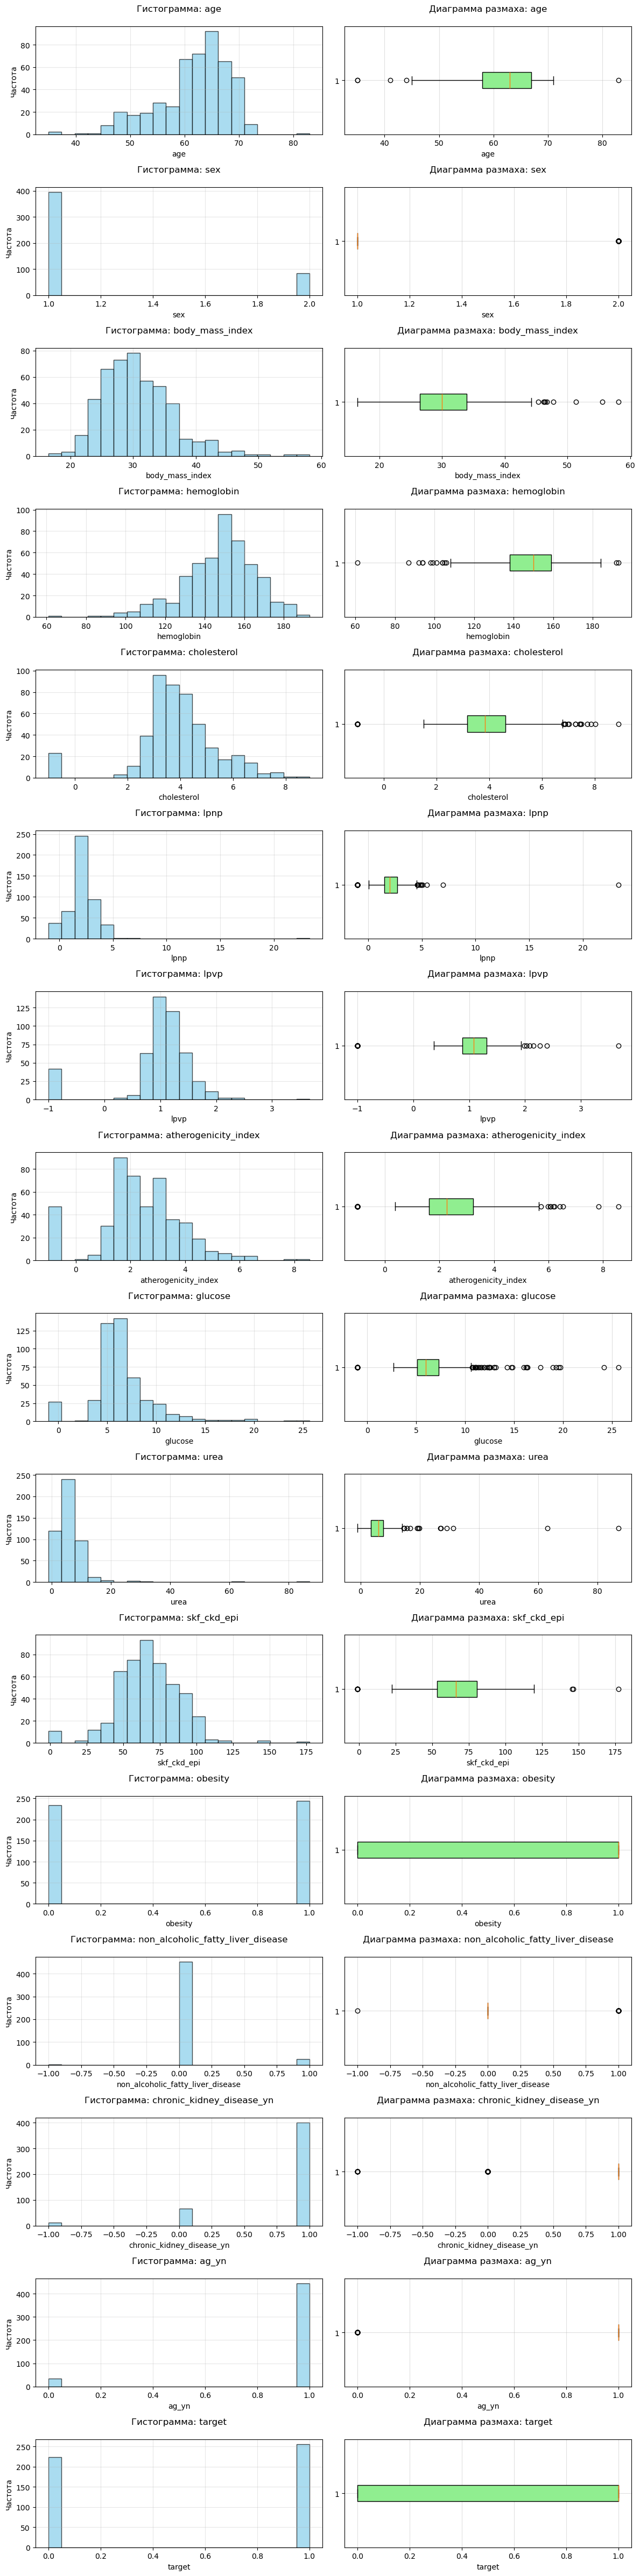

,age,sex,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,obesity,non_alcoholic_fatty_liver_disease,chronic_kidney_disease_yn,ag_yn,target
count,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00,478.00
mean,61.75,1.18,30.54,147.73,3.87,2.10,0.97,2.35,6.44,5.73,67.23,0.51,0.05,0.81,0.93,0.53
std,6.58,0.38,5.65,18.18,1.59,1.58,0.69,1.58,3.30,6.51,21.67,0.50,0.23,0.44,0.26,0.50
min,35.00,1.00,16.52,61.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,0.00,-1.00,-1.00,0.00,0.00
25%,58.00,1.00,26.50,138.00,3.17,1.51,0.88,1.62,5.08,3.50,53.55,0.00,0.00,1.00,1.00,0.00
50%,63.00,1.00,30.02,150.00,3.84,2.04,1.08,2.26,5.98,6.01,66.24,1.00,0.00,1.00,1.00,1.00
75%,67.00,1.00,33.90,159.00,4.62,2.72,1.31,3.24,7.32,7.80,80.74,1.00,0.00,1.00,1.00,1.00
max,83.00,2.00,58.13,193.00,8.90,23.32,3.67,8.56,25.66,87.00,177.31,1.00,1.00,1.00,1.00,1.00


In [30]:
# числовые признаки
numeric_columns = data.select_dtypes(include=['int', 'float']).columns.tolist()

# графики числовых признаков
quantitative_data(data, numeric_columns)

**Портрет пациента из наших данных:**

Это мужчина около 65 лет, с ИМТ = 30, с высоким, около 150, гемоглобином, с уровнем холестерина 4, с lpnp = 2.04, lpvp = 1.08, с индексом атерогенности = 2.26, с уровнем глюкозы = 5.98, мочевиной = 6, СКФ = 66.24, с ожирением, без НЕАЖБП, с ХБП, с артериальной гипертензией и СД.


Стоит обратить внимание, что количество мужчин у нас сильно преобладают над женщинами. 
Целевая переменная распределена примерно поровну.

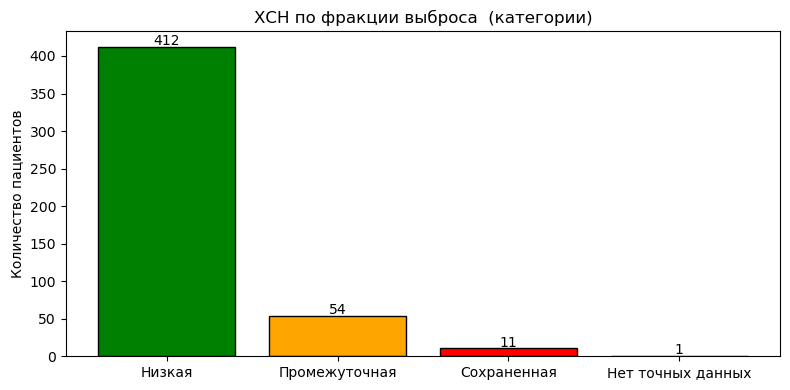

Количество пациентов по категориям:
Низкая: 412
Промежуточная: 54
Сохраненная: 11
Нет точных данных: 1


In [31]:
# считаем количество в каждой категории
counts = data['hsn_category'].value_counts()

# столбчатая диаграмма
plt.figure(figsize=(8, 4))

plt.bar(counts.index, counts.values, 
        color=['green', 'orange', 'red', 'gray'], 
        edgecolor='black')

plt.title('ХСН по фракции выброса  (категории)')
plt.ylabel('Количество пациентов')

# добавим числа на столбцы
for i, value in enumerate(counts.values):
    plt.text(i, value + 2, str(value), ha='center')

plt.tight_layout()
plt.show()

# Выводим статистику
print("Количество пациентов по категориям:")
for category, count in counts.items():
    print(f"{category}: {count}")

**Вывод:** Провели исследовательский анализ. Вывели описательный портрет пациента: 

Это мужчина около 65 лет, с ИМТ = 30, с высоким, около 150, гемоглобином, с уровнем холестерина 4, с lpnp = 2.04, lpvp = 1.08, с индексом атерогенности = 2.26, с уровнем глюкозы = 5.98, мочевиной = 6, СКФ = 66.24, с ожирением, без НЕАЖБП, с ХБП, с артериальной гипертензией и СД.

# Коррелляционный анализ

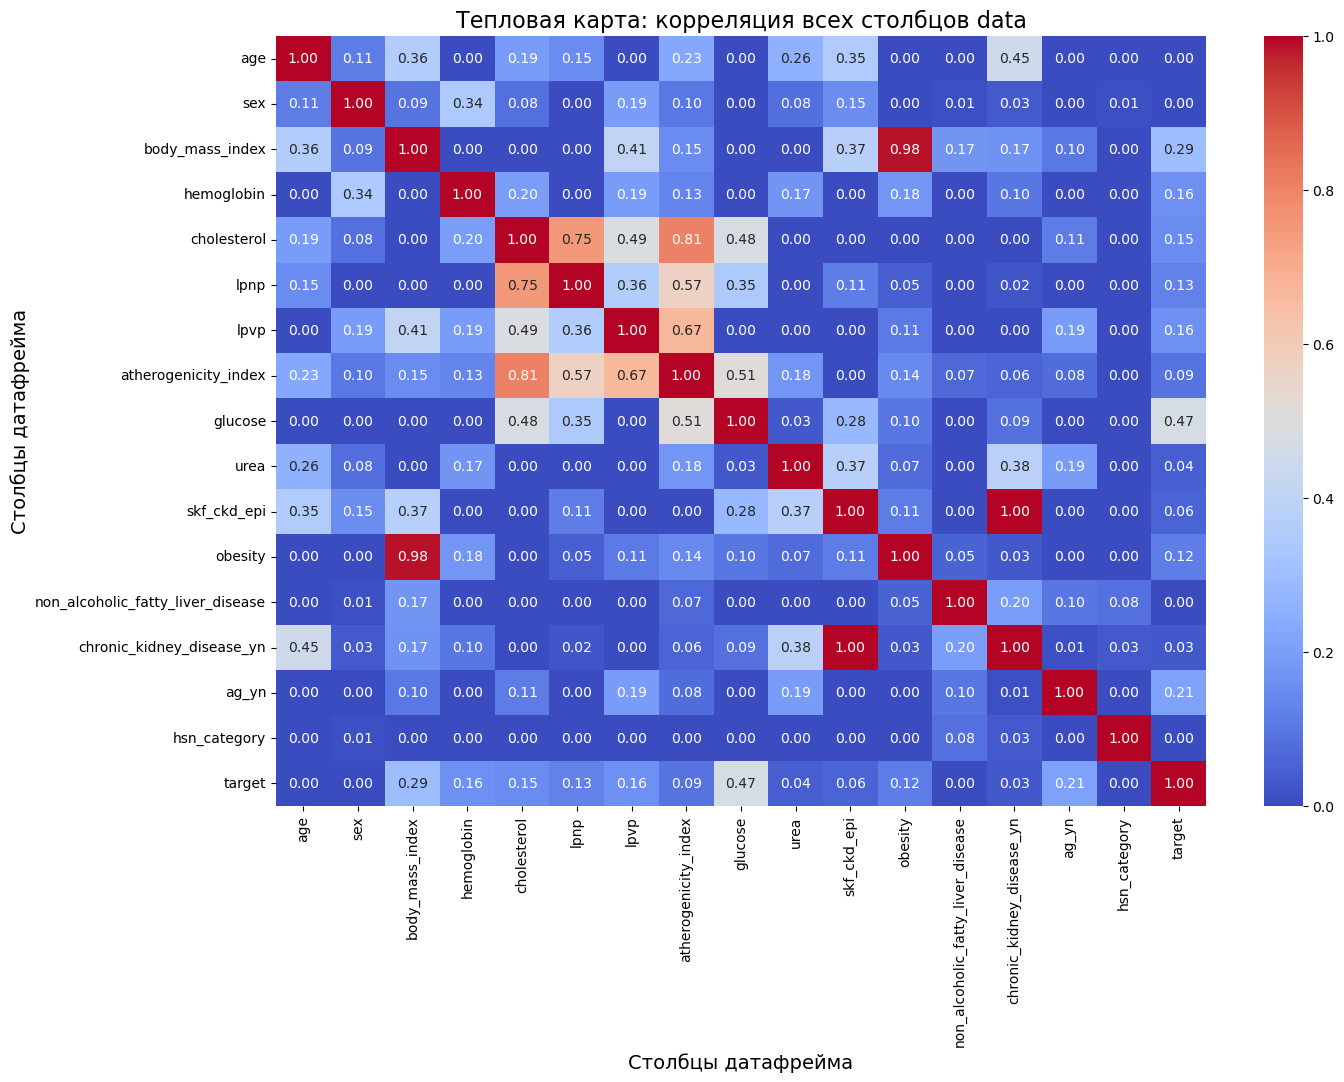

In [32]:
# карта корреляции heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(data.phik_matrix(interval_cols = [
                'age', 'sex', 'body_mass_index', 'hemoglobin', 'cholesterol',
                'lpnp', 'lpvp', 'atherogenicity_index', 'glucose', 'urea', 
                'skf_ckd_epi', 'obesity', 'non_alcoholic_fatty_liver_disease', 
                'chronic_kidney_disease_yn', 'ag_yn', 'target']
                        ),
            annot=True, 
            fmt='.2f',
            cmap='coolwarm')

plt.title('Тепловая карта: корреляция всех столбцов data',
          fontsize=16)
plt.xlabel('Столбцы датафрейма', fontsize=14)
plt.ylabel('Столбцы датафрейма', fontsize=14)
plt.show()

Наблюдаем прямую связь между ожирением и ИМТ, ХПН и СКФ, на таргет не влияют возраст, пол, НАЖБП, ХСН.

Видим ожидаемую высокую корреляцию между ЛПНП (corr=0.75) и индексом атерогенности(corr=0.81) с холестерином.

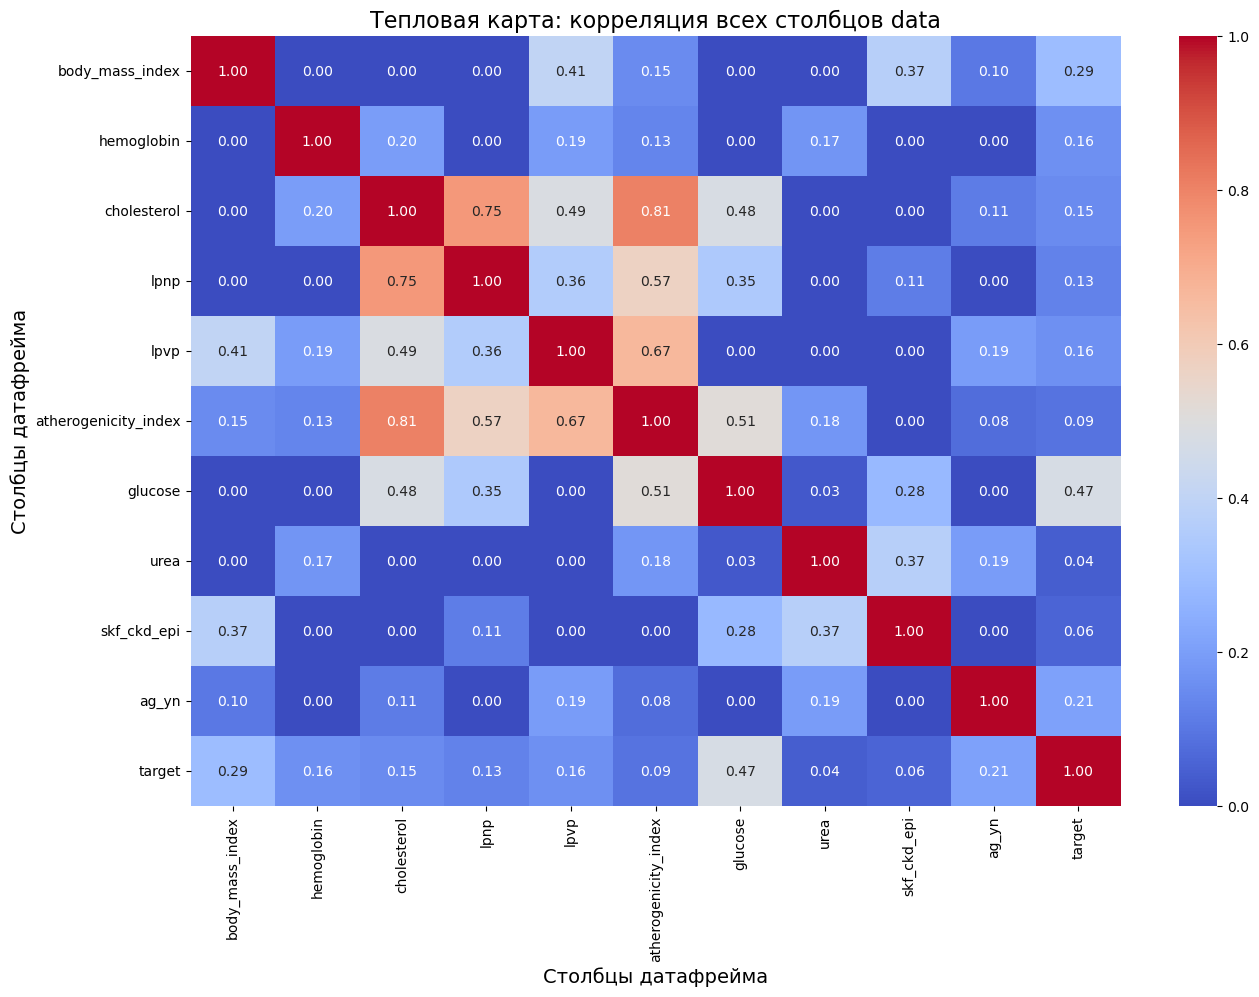

In [33]:
# удалим признаки
data = data.drop(columns = ['obesity', 'chronic_kidney_disease_yn', 'age', 'sex', 
                            'non_alcoholic_fatty_liver_disease', 'hsn_category'])

# карта корреляции heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(data.phik_matrix(interval_cols = [
    'body_mass_index', 'hemoglobin', 'cholesterol',
    'lpnp', 'lpvp', 'atherogenicity_index', 'glucose',
    'urea', 'skf_ckd_epi', 'ag_yn', 'target']
                            ),
            annot=True, 
            fmt='.2f',
            cmap='coolwarm')

plt.title('Тепловая карта: корреляция всех столбцов data',
          fontsize=16)
plt.xlabel('Столбцы датафрейма', fontsize=14)
plt.ylabel('Столбцы датафрейма', fontsize=14)
plt.show()

**Вывод:**
Провели корреляционный анализ. Обнаружили мультиколлинеарность в данных и устранили её. Удалили признаки, не влияющие на target.

# Подготовка данных

Разделим данные на тренировочную и обучающую выборки.

In [34]:
# входные признаки
X = data.drop(['target'], axis=1)

# целевой признак
y = data['target']

# разбивка данных
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE)

display(X_train.tail())

,body_mass_index,hemoglobin,cholesterol,lpnp,lpvp,atherogenicity_index,glucose,urea,skf_ckd_epi,ag_yn
171,29.74,131,5.81,3.79,1.55,2.75,5.32,7.09,67.87,1
127,26.37,147,2.63,1.13,1.31,1.01,7.10,-1.00,145.90,1
255,30.49,148,4.42,2.03,1.55,1.85,4.59,-1.00,74.78,1
422,22.78,156,3.60,1.40,1.46,1.47,5.12,-1.00,92.91,1
0,34.45,163,4.14,2.25,0.97,3.27,5.77,-1.00,65.46,1


**Вывод:**  подготовили данные к обучению: разделили выборку на тренировочную и тестовую.

# Обучение моделей машинного обучения

Для предсказания, есть ли у пациента сахарный диабет, будем использовать модели: 

- LogisticRegression, 
- DecisionTreeClassifier, 
- LightGBMClassifier, 
- CatBoost Classifier

## LogisticRegression

In [35]:
model_lr = LogisticRegression(random_state=RANDOM_STATE)

# Параметры
lr_params = {
    'C': [5, 10, 13, 16, 20],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# создадим scorer для F1-macro
f1_macro = make_scorer(f1_score, average='macro')

lr_grid = GridSearchCV(
    model_lr,
    lr_params,
    cv=5,
    scoring=f1_macro,
    n_jobs=-1)

lr_grid.fit(X_train, y_train)
f1_lr = lr_grid.best_score_

print("=== Logistic Regression ===")
print(f"Лучшие параметры: {lr_grid.best_params_}")
print(f"Лучшая F1_macro: {f1_lr:.4f}")

=== Logistic Regression ===
Лучшие параметры: {'C': 16, 'penalty': 'l1', 'solver': 'liblinear'}
Лучшая F1_macro: 0.6808


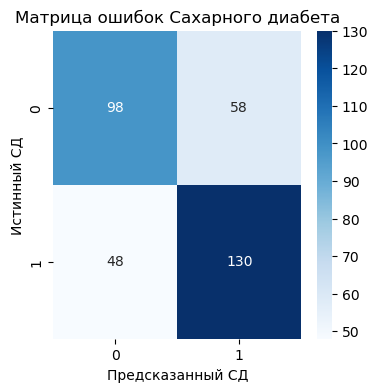

In [36]:
# предсказания на тренировочных данных
y_pred_lr = lr_grid.best_estimator_.predict(X_train)

# Матрица ошибок
cm = confusion_matrix(y_train, y_pred_lr)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

Модель 48 раз ошибается, предсказав отсутствие диабета, и 58 раз, предсказав наличие.

## RandomForest

In [37]:
model_rf = RandomForestClassifier(
    random_state=RANDOM_STATE, 
    n_jobs=-1)

# Параметры для RandomForest
rf_params = {
    'criterion': ['gini'],
    'n_estimators': [150, 200, 250],
    'max_depth': [10, 15, 17],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True]
}

rf_grid = GridSearchCV(
    model_rf,
    rf_params,
    cv=5,
    scoring=f1_macro,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
f1_rf = rf_grid.best_score_

print("=== RandomForest ===")
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучшая F1_macro: {f1_rf:.4f}")

=== RandomForest ===
Лучшие параметры: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая F1_macro: 0.7210


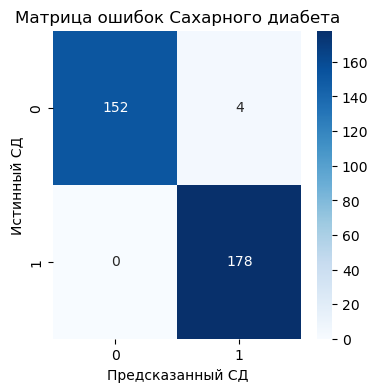

In [38]:
# предсказания на тренировочных данных
y_pred_rf = rf_grid.best_estimator_.predict(X_train)

# Матрица ошибок
cm = confusion_matrix(y_train, y_pred_rf)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

Модель не ошибается ни разу, предсказав отсутствие диабета, и 4 раз, предсказав наличие. Согласно матрице ошибок модель достаточно хороша, чтобы её тоже протестировать.

## LGBM Classifier

In [39]:
model_lgbm = LGBMClassifier(random_state=RANDOM_STATE)

# Параметры для LightGBM
lgb_params = {
    'n_estimators': [140, 150, 170],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 1]
}

lgb_grid = GridSearchCV(
    model_lgbm,
    lgb_params,
    cv=5,
    scoring=f1_macro,
    n_jobs=-1,
    verbose=0
)

lgb_grid.fit(X_train, y_train)
f1_lgb = lgb_grid.best_score_

print("=== LightGBM ===")
print(f"Лучшие параметры: {lgb_grid.best_params_}")
print(f"Лучшая F1_macro: {f1_lgb:.4f}")


[LightGBM] [Info] Number of positive: 178, number of negative: 156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 823
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532934 -> initscore=0.131928
[LightGBM] [Info] Start training from score 0.131928
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

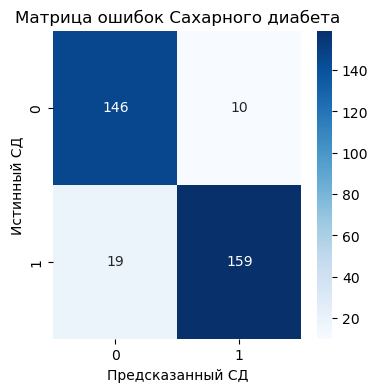

In [40]:
# предсказания на тренировочных данных
y_pred_lgb = lgb_grid.best_estimator_.predict(X_train)

# Матрица ошибок
cm = confusion_matrix(y_train, y_pred_lgb)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

Модель 19 раз ошибается, предсказав отсутствие диабета, и 10 раз, предсказав наличие.

## CatBoostClassifier

In [41]:
model_cat = CatBoostClassifier(
    random_state=RANDOM_STATE, 
    verbose=100)

# Параметры для CatBoost
cat_params = {
    'depth': [1, 2, 3], 
    'learning_rate': [0.1, 1, 3], 
    'n_estimators': [90, 100, 150]
}

cat_grid = GridSearchCV(
    model_cat,
    cat_params,
    cv=5,
    scoring=f1_macro,
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)
f1_cat = cat_grid.best_score_

print("=== CatBoost ===")
print(f"Лучшие параметры: {cat_grid.best_params_}")
print(f"Лучшая F1_macro: {f1_cat:.4f}")

0:	learn: 0.6025347	total: 151ms	remaining: 15s
99:	learn: 0.3184663	total: 175ms	remaining: 0us
=== CatBoost ===
Лучшие параметры: {'depth': 1, 'learning_rate': 1, 'n_estimators': 100}
Лучшая F1_macro: 0.7387


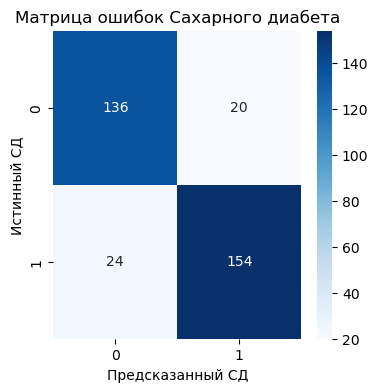

In [42]:
# предсказания на тренировочных данных
y_pred_cat = cat_grid.best_estimator_.predict(X_train)

# Матрица ошибок
cm = confusion_matrix(y_train, y_pred_cat)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

Модель 24 раза ошибается, предсказав отсутствие диабета, и 20 раз, предсказав наличие.

In [43]:
# DataFrame с результатами
results = pd.DataFrame({
    'Модель': ['LogisticRegression', 'RandomForest', 'LightGBM', 'CatBoost'],
    'F1_macro': [round(f1_lr,4), round(f1_rf,4), round(f1_lgb,4), round(f1_cat,4)],
})

# сортировка по ROC_AUC
display(results.sort_values('F1_macro', ascending=False))

,Модель,F1_macro
2,LightGBM,0.75
3,CatBoost,0.74
1,RandomForest,0.72
0,LogisticRegression,0.68


**Вывод:** Обучили 4 модели. Получили следующие метрики F1_macro:

- LightGBM	= 0.75
- CatBoost	= 0.74
- RandomForest	= 0.72
- LogisticRegression	= 0.68

Лучшая модель **LGBMClassifier** с гиперпараметрами {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}

# Тестирование модели

Протестируем 2 модели по лучшей метрике - LightGBM, и по лучшей матрице ошибок - Random Forest.

In [44]:
# лучшая модель из общего GridSearchCV
best_model = lgb_grid.best_estimator_

# предсказания на тестовых данных
y_pred_test = best_model.predict(X_test)

# метрики на тестовых данных
test_f1 = f1_score(y_test, y_pred_test, average='macro')
test_accuracy = accuracy_score(y_test, y_pred_test)

print("МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ:")
print(f"f1_score: {test_f1:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")

МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ:
f1_score: 0.7269
Accuracy: 0.7292


In [45]:
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.7375
Recall: 0.7662


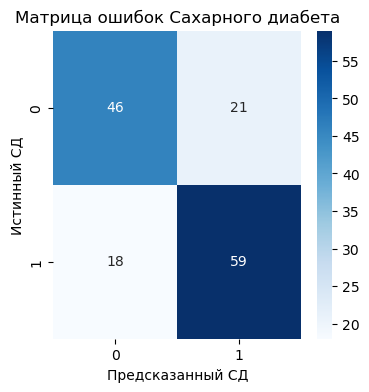

In [46]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_test)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

Модель 18 раз пропускает больных с СД, 21 раз приписывает болезнь здоровому человеку. 46 раз верно определила здоровых, 59 раз - больных.

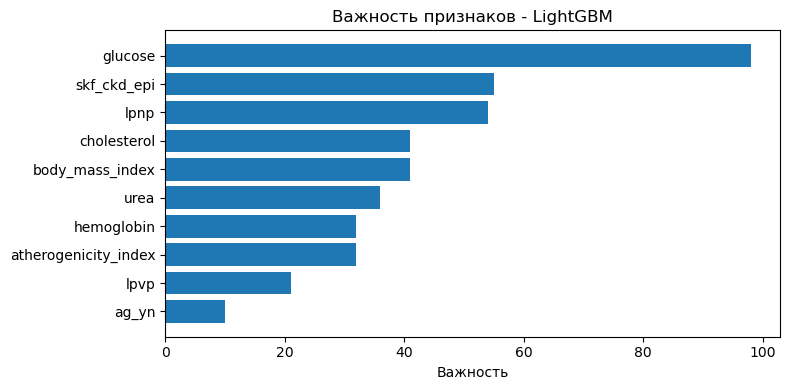

,Feature,Importance
9,ag_yn,10
4,lpvp,21
5,atherogenicity_index,32
1,hemoglobin,32
7,urea,36
0,body_mass_index,41
2,cholesterol,41
3,lpnp,54
8,skf_ckd_epi,55
6,glucose,98


In [47]:
# важность признаков
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

# График
plt.figure(figsize=(8, 4))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Важность признаков - LightGBM')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

display(feature_importance.round(2))

In [48]:
# лучшая модель RandomForest
best_model_rf = rf_grid.best_estimator_

# предсказания на тестовых данных
y_pred_test_rf = best_model_rf.predict(X_test)

# метрики на тестовых данных
test_f1_rf = f1_score(y_test, y_pred_test_rf, average='macro')
test_accuracy_rf = accuracy_score(y_test, y_pred_test_rf)

print("МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ:")
print(f"f1_score: {test_f1_rf:.4f}")
print(f"Accuracy: {test_accuracy_rf:.4f}")

МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ:
f1_score: 0.7037
Accuracy: 0.7083


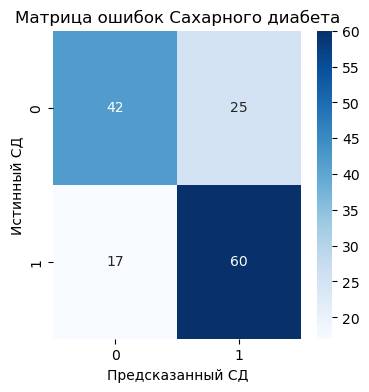

In [49]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_test_rf)

# Визуализация
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок Сахарного диабета',
          fontsize=12)
plt.ylabel('Истинный СД')
plt.xlabel('Предсказанный СД')
plt.show()

**Вывод**: 
Протестировали 2 модели LightGBM и Random Forest, получили метрики:
 - для **LightGBM**:
    - F1_macro = 0.73
    - Accuracy = 0.73

Наиболее важными признаками являются:

- показатель глюкозы `glucose`,
- скорость клубочковой фильтрации (СКФ) - показатель функционального состояния почек `skf_cks_epi`,
- анализ крови на липопротеины низкой плотности (ЛПНП) — исследование, которое определяет уровень «плохого» холестерина `lpnp`.


 - для **Random Forest**:
    - F1_macro = 0.70
    - Accuracy = 0.71

Согласно матрице ошибок модель Random Forest меньше ошибается, определяя отсутствие СД, и чуть лучше определяяет наличие СД. Хуже предсказывает отсутствие СД, и больше ошибается, предсказав наличие диабета.

# Общие выводы

Перед нами стояла задача спрогнозировать болезнь сахарного диабета. Для этого мы предобработали данные: привели названия столбцов к змеиному регистру, тип данных привели к соответствующему типу в столбцах. Проверили данные на пропуски, на явные и неявные дубликаты. Они отсутствовали.

Провели исследовательский анализ и вывели описательный портрет пациента: 

Это мужчина около 65 лет, с ИМТ = 30, с высоким, около 150, гемоглобином, с уровнем холестерина 4, с lpnp = 2.04, lpvp = 1.08, с индексом атерогенности = 2.26, с уровнем глюкозы = 5.98, мочевиной = 6, СКФ = 66.24, с ожирением, без НЕАЖБП, с ХБП, с артериальной гипертензией и СД.

Провели корреляционный анализ. Нашли мультиколлинеарность между признаками и устранили ее. Удалили признаки, не влияющие на target.

Подготовили данные к обучению: разделили выборку на тренировочную и тестовую. Тк все признаки числовые, то масштабировать их не стали.

Обучили 4 модели. Получили следующие метрики F1_macro:

- LightGBM	= 0.75
- CatBoost	= 0.74
- RandomForest	= 0.72
- LogisticRegression	= 0.68

Лучшая модель **LGBMClassifier** с гиперпараметрами {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}

Протестировали модель LightGBM, получили метрики:

- F1_macro = 0.73
- Accuracy = 0.73

для **Random Forest**:
    
    - F1_macro = 0.70
    - Accuracy = 0.71

Наиболее важными признаками являются:

- показатель глюкозы `glucose`,
- скорость клубочковой фильтрации (СКФ) - показатель функционального состояния почек `skf_cks_epi`,
- анализ крови на липопротеины низкой плотности (ЛПНП) — исследование, которое определяет уровень «плохого» холестерина `lpnp`